# MLP Regression Test AION

## Load Embeddings and Catalogs

In [1]:
import numpy as np
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
from astropy.io import fits
from astropy.table import Table
import umap
import time
from scipy.stats import spearmanr

embeddings_path = "/pbs/throng/training/astroinfo2025/work/maxime/data_all_tokens_spectrums.pt"

print("Loading AION embeddings...")
data = torch.load(embeddings_path, map_location="cpu")

# Inspect the data structure
print(f"\nData type: {type(data)}")
if isinstance(data, list):
    print(f"Number of records: {len(data)}")
    if len(data) > 0:
        print(f"\nFirst record keys: {list(data[0].keys())}")
elif isinstance(data, dict):
    print(f"Dictionary keys: {list(data.keys())}")
else:
    print(f"Unexpected data type: {type(data)}")

records = data if isinstance(data, list) else [data]

Loading AION embeddings...

Data type: <class 'list'>
Number of records: 15263

First record keys: ['object_id', 'redshift', 'embedding_hsc_desi', 'embedding_hsc', 'embedding_spectrum', 'tokens_hsc_desi', 'tokens_hsc', 'tokens_spectrum']


In [3]:


def stack_embeddings(records, key):
    """Extract and stack embeddings for a given key."""
    vectors = []
    valid_indices = []
    
    for idx, rec in enumerate(records):
        tensor = rec.get(key)
        if tensor is None:
            continue
        if isinstance(tensor, torch.Tensor):
            vectors.append(tensor.detach().cpu().numpy())
            valid_indices.append(idx)
        else:
            vectors.append(np.asarray(tensor))
            valid_indices.append(idx)
    
    if not vectors:
        raise ValueError(f"No embeddings found for key '{key}'")
    
    return np.stack(vectors, axis=0), np.array(valid_indices)

# Extract AION embeddings
print("Extracting embeddings by type...")

## Spectra-only embeddings
#try:
#    emb_spectra, idx_spectra = stack_embeddings(records, "embedding_spectrum")
#    print(f"✓ Spectra-only (DESI): {emb_spectra.shape}")
#    has_spectra = True
#except (ValueError, KeyError) as e:
#    print(f"⚠ Spectra-only embeddings not found (key: 'embedding_spectra')")
#    emb_spectra = None
#    has_spectra = False

# Image-only embeddings
#test_embeddings, idx_image = stack_embeddings(records, "embedding_hsc")
#print(f"✓ Image-only (Euclid): {test_embeddings.shape}")

# Multimodal embeddings (spectra + image)
test_embeddings, idx_multimodal = stack_embeddings(records, "embedding_hsc_desi")
print(f"✓ Multimodal (spectra+image): {test_embeddings.shape}")

print(f"\nTotal records processed: {len(records)}")



Extracting embeddings by type...
✓ Multimodal (spectra+image): (15263, 768)

Total records processed: 15263


/pbs/throng/training/astroinfo2025/env/astroclip-conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


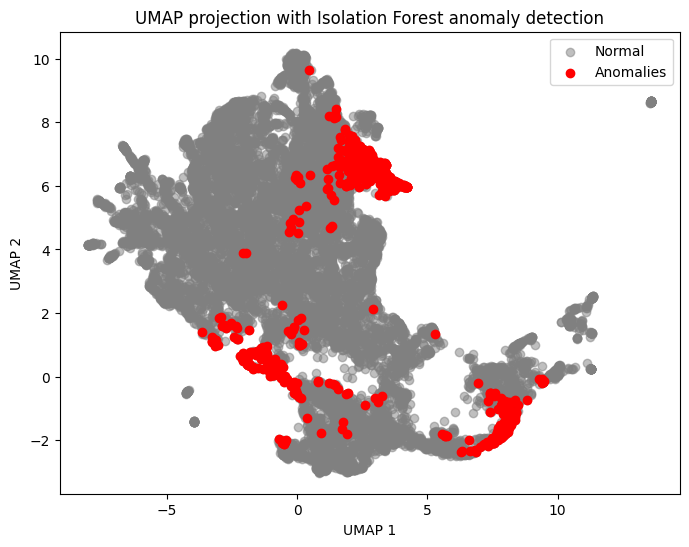

Found 764 anomalies using Isolation Forest with contamination=0.05


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.ensemble import IsolationForest

# Convert embeddings tensor to numpy array if needed
if hasattr(test_embeddings, 'cpu'):
    emb_np = test_embeddings.cpu().numpy()
else:
    emb_np = test_embeddings

# 1. Fit Isolation Forest for anomaly detection
contamination = 0.05  # 5% of data expected to be anomalies, adjust as needed
iso_forest = IsolationForest(contamination=contamination, random_state=42)
iso_forest.fit(emb_np)

# 2. Predict anomalies: -1 is anomaly, 1 is normal
anomaly_labels = iso_forest.predict(emb_np)
anomalies = np.where(anomaly_labels == -1)[0]

# 3. Visualization with UMAP
reducer = umap.UMAP(random_state=42)
embedding_2d = reducer.fit_transform(emb_np)

plt.figure(figsize=(8, 6))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c='gray', alpha=0.5, label='Normal')
plt.scatter(embedding_2d[anomalies, 0], embedding_2d[anomalies, 1], color='red', label='Anomalies')
plt.legend()
plt.title('UMAP projection with Isolation Forest anomaly detection')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

print(f"Found {len(anomalies)} anomalies using Isolation Forest with contamination={contamination}")


In [5]:
# Extract object IDs from records
object_ids = []

for rec in records:
    # The 'object_id' field in embeddings actually contains DESI TARGETID
    obj_id = rec.get('object_id')
    object_ids.append(obj_id if obj_id is not None else np.nan)
    
 

object_ids = np.array(object_ids, dtype=np.int64)

print(f"\nObject IDs extracted: {len(object_ids)}")
print(f"Object ID type: {object_ids.dtype}")
print(f"Sample IDs: {object_ids[:10]}")



Object IDs extracted: 15263
Object ID type: int64
Sample IDs: [2717133723668032087 2697025639635422031 2689998354648490199
 2673429640659180447 2692292598651618549 2687626215633207816
 2732016874663066226 2671271269651071277 2719376602668193972
 2709000536659884221]


In [6]:
# Match embeddings with catalog
# The embeddings 'object_id' field contains Euclid object_id values
# The catalog has both: 'object_id' (Euclid) and 'TARGETID' (DESI)
# We need to match using object_id (Euclid ID)

print("Matching embeddings with catalog...")

# Path to the combined DESI-Euclid catalog
catalog_path = "/pbs/throng/training/astroinfo2025/data/astroPT_euclid_desi_dataset/desi_euclid_catalog.fits"

print("Loading catalog...")
with fits.open(catalog_path) as hdul:
    catalog = Table(hdul[1].data)

print(f"✓ Catalog loaded: {len(catalog)} entries")
#print(f"✓ Available columns ({len(catalog.colnames)}):")
#for i, col in enumerate(catalog.colnames[:20]):  # Show first 20 columns
#    print(f"  {col}")
#if len(catalog.colnames) > 20:
#    print(f"  ... and {len(catalog.colnames) - 20} more")
print(f"  Embeddings: {len(object_ids)} objects")
print(f"  Catalog: {len(catalog)} entries (matched Euclid+DESI objects)")

# Use object_id for matching (Euclid object ID)
id_column = 'object_id'

# Create mapping from object_id to catalog index
catalog_ids = np.array(catalog[id_column], dtype=np.int64)
# Filter out null values
valid_mask = catalog_ids > 0
valid_catalog_ids = catalog_ids[valid_mask]
valid_catalog_indices = np.where(valid_mask)[0]

# Create dictionary with int64 keys to match embedding IDs
id_to_idx = {np.int64(tid): idx for tid, idx in zip(valid_catalog_ids, valid_catalog_indices)}

print(f"\nCatalog mapping created: {len(id_to_idx)} valid object_id entries")
print(f"Sample catalog object_ids: {valid_catalog_ids[:5]}")
print(f"Sample embedding object_ids: {object_ids[:5]}")

# Match embeddings to catalog
matched_indices = []
unmatched_ids = []

for obj_id in object_ids:
    # Ensure obj_id is np.int64 for consistent lookup
    obj_id = np.int64(obj_id)
    if obj_id in id_to_idx:
        matched_indices.append(id_to_idx[obj_id])
    else:
        matched_indices.append(-1)
        unmatched_ids.append(obj_id)

matched_indices = np.array(matched_indices)
n_matched = (matched_indices >= 0).sum()
match_rate = n_matched / len(object_ids) * 100

print(f"\n{'='*60}")
print(f"MATCHING RESULTS")
print(f"{'='*60}")
print(f"✓ Matched: {n_matched}/{len(object_ids)} ({match_rate:.1f}%)")

if len(unmatched_ids) > 0:
    print(f"⚠ Unmatched: {len(unmatched_ids)} ({100-match_rate:.1f}%)")
    if len(unmatched_ids) <= 10:
        print(f"  Unmatched object_ids: {unmatched_ids}")
    else:
        print(f"  Sample unmatched object_ids: {unmatched_ids[:5]}")
        # Check if any embedding IDs are in the catalog at all
        emb_set = set(object_ids)
        cat_set = set(valid_catalog_ids)
        overlap = len(emb_set & cat_set)
        print(f"  Set intersection check: {overlap} common IDs")
else:
    print(f"✓ Perfect match! All embeddings found in catalog.")

print(f"{'='*60}")

Matching embeddings with catalog...
Loading catalog...
✓ Catalog loaded: 15999 entries
  Embeddings: 15263 objects
  Catalog: 15999 entries (matched Euclid+DESI objects)

Catalog mapping created: 15263 valid object_id entries
Sample catalog object_ids: [2703033710652702582 2663761326630989450 2664725668631204412
 2664861406630859837 2664992276631166766]
Sample embedding object_ids: [2717133723668032087 2697025639635422031 2689998354648490199
 2673429640659180447 2692292598651618549]

MATCHING RESULTS
✓ Matched: 15263/15263 (100.0%)
✓ Perfect match! All embeddings found in catalog.


In [7]:
# Extract physical properties from catalog
def safe_extract(column_name):
    """Extract column values, filling unmatched entries with NaN"""
    if column_name not in catalog.colnames:
        print(f"⚠ Column '{column_name}' not found in catalog")
        return np.full(len(matched_indices), np.nan, dtype=float)
    
    values = np.full(len(matched_indices), np.nan, dtype=float)
    mask = matched_indices >= 0
    values[mask] = catalog[column_name][matched_indices[mask]]
    return values

def safe_extract_string(column_name):
    """Extract string column values, filling unmatched entries with empty string"""
    if column_name not in catalog.colnames:
        print(f"⚠ Column '{column_name}' not found in catalog")
        return np.full(len(matched_indices), '', dtype=object)
    
    values = np.full(len(matched_indices), '', dtype=object)
    mask = matched_indices >= 0
    values[mask] = [s.strip() if isinstance(s, (str, bytes)) else str(s) for s in catalog[column_name][matched_indices[mask]]]
    return values

print("Extracting physical properties from catalog...\n")



logm = safe_extract('LOGM')              # Stellar mass
logsfr = safe_extract('LOGSFR')          # Star formation rate
dn4000 = safe_extract('DN4000')          # 4000Å break
gr_color = safe_extract('GR')            # g-r color
spectype = safe_extract_string('SPECTYPE')  # Spectral type

# Derived spectral properties
ssfr = logsfr - logm  # Specific SFR

# Image/morphological properties from Euclid
ellipticity = safe_extract('ellipticity')                        # Ellipticity
kron_radius = safe_extract('kron_radius')                        # Kron radius (size)
concentration = safe_extract('concentration')                     # Concentration index
asymmetry = safe_extract('asymmetry')                            # Asymmetry
smoothness = safe_extract('smoothness')                          # Smoothness/clumpiness
gini = safe_extract('gini')                                      # Gini coefficient
sersic_index = safe_extract('sersic_sersic_vis_index')          # Sérsic index
sersic_radius = safe_extract('sersic_sersic_vis_radius')        # Sérsic radius
axis_ratio = safe_extract('sersic_sersic_vis_axis_ratio')       # Axis ratio

# Additional morphological features
has_spiral_arms = safe_extract('has_spiral_arms_yes')           # Spiral arms presence
disk_edge_on = safe_extract('disk_edge_on_yes')                 # Edge-on disk
det_quality_flag = safe_extract('det_quality_flag')             # Detection quality flag

# Print statistics
print("✓ Spectral/Physical property statistics:")
spectral_properties = {
    'LOGM (stellar mass)': logm,
    'LOGSFR': logsfr,
    'sSFR (log)': ssfr,
    'DN4000': dn4000,
    'g-r color': gr_color
}

for name, values in spectral_properties.items():
    valid = ~np.isnan(values)
    if valid.sum() > 0:
        print(f"  {name}: {np.nanmean(values):.2f} ± {np.nanstd(values):.2f} (n={valid.sum()})")
    else:
        print(f"  {name}: No valid data")

print("\n✓ Morphological property statistics:")
morphological_properties = {
    'Ellipticity': ellipticity,
    'Kron radius': kron_radius,
    'Concentration': concentration,
    'Asymmetry': asymmetry,
    'Smoothness': smoothness,
    'Gini': gini,
    'Sérsic index': sersic_index,
    'Sérsic radius': sersic_radius,
    'Axis ratio': axis_ratio,
    'Has spiral arms': has_spiral_arms,
    'Disk edge-on': disk_edge_on,
    'Detection quality': det_quality_flag
}

for name, values in morphological_properties.items():
    valid = ~np.isnan(values)
    if valid.sum() > 0:
        print(f"  {name}: {np.nanmean(values):.2f} ± {np.nanstd(values):.2f} (n={valid.sum()})")
    else:
        print(f"  {name}: No valid data")

# Spectral types
unique_spectypes = np.unique(spectype[spectype != ''])
if len(unique_spectypes) > 0:
    print(f"\n✓ Spectral types found: {list(unique_spectypes)}")
    for stype in unique_spectypes:
        count = (spectype == stype).sum()
        print(f"  {stype}: {count:,} ({100*count/len(spectype):.1f}%)")

Extracting physical properties from catalog...

✓ Spectral/Physical property statistics:
  LOGM (stellar mass): 9.69 ± 2.73 (n=15136)
  LOGSFR: -2.01 ± 4.45 (n=15136)
  sSFR (log): -11.70 ± 5.61 (n=15136)
  DN4000: 1.54 ± 0.60 (n=15263)
  g-r color: 0.50 ± 0.83 (n=15136)

✓ Morphological property statistics:
  Ellipticity: 0.34 ± 0.19 (n=15263)
  Kron radius: 88.39 ± 51.67 (n=15263)
  Concentration: 3.48 ± 0.69 (n=15263)
  Asymmetry: 0.29 ± 0.15 (n=15263)
  Smoothness: 0.22 ± 0.08 (n=15263)
  Gini: 0.66 ± 0.09 (n=15263)
  Sérsic index: 2.30 ± 1.65 (n=15263)
  Sérsic radius: 1.66 ± 2.46 (n=15263)
  Axis ratio: 0.64 ± 0.21 (n=15263)
  Has spiral arms: 43.22 ± 34.89 (n=13505)
  Disk edge-on: 14.42 ± 23.99 (n=13505)
  Detection quality: 24.47 ± 102.09 (n=15263)

✓ Spectral types found: ['GALAXY', 'QSO']
  GALAXY: 15,135 (99.2%)
  QSO: 128 (0.8%)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    test_embeddings, morphological_properties['Ellipticity'], test_size=0.2, random_state=42)

## MLP Regression

### MLPRegressor

In [9]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score

# X_train, X_test: AstroCLIP embeddings for train and test galaxies
# y_train, y_test: known physical properties

mlp = MLPRegressor(hidden_layer_sizes=(32,), max_iter=500)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
score = r2_score(y_test, y_pred)
print(f"MLP Regression R^2 score: {score:.3f}")

MLP Regression R^2 score: 0.379


### Small MLP

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# Example data: X are AstroCLIP embeddings, y are galaxy physical properties (e.g. stellar mass)
# Replace with your dataset
#X = np.array(...)  # shape: (num_samples, embedding_dim)
#y = np.array(...)  # shape: (num_samples, num_properties)

# Train/test split
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# Standardize features and targets
scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)

X_train = scaler_X.transform(X_train)
X_test = scaler_X.transform(X_test)
y_train = scaler_y.transform(y_train)
y_test = scaler_y.transform(y_test)

# Convert to torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# Define a deeper MLP regression model
class MLPRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLPRegression, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim),
        )
        
    def forward(self, x):
        return self.network(x)

# Instantiate model, loss, optimizer
input_dim = X_train.shape[1]
output_dim = y_train.shape[1] if len(y_train.shape) > 1 else 1

model = MLPRegression(input_dim, output_dim)
criterion = nn.MSELoss()  # Mean Squared Error loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 200
model.train()
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_t).numpy()
    y_pred_test = model(X_test_t).numpy()

# Inverse transform to original scale
y_pred_train_orig = scaler_y.inverse_transform(y_pred_train)
y_pred_test_orig = scaler_y.inverse_transform(y_pred_test)
y_train_orig = scaler_y.inverse_transform(y_train)
y_test_orig = scaler_y.inverse_transform(y_test)

# Metrics
r2_train = r2_score(y_train_orig, y_pred_train_orig)
r2_test = r2_score(y_test_orig, y_pred_test_orig)
mae_test = mean_absolute_error(y_test_orig, y_pred_test_orig)

print(f"Train R^2: {r2_train:.3f}")
print(f"Test R^2: {r2_test:.3f}")
print(f"Test MAE: {mae_test:.3f}")


Epoch [50/200], Loss: 0.9890
Epoch [100/200], Loss: 0.9736
Epoch [150/200], Loss: 0.9636
Epoch [200/200], Loss: 0.9534
Train R^2: 0.054
Test R^2: -0.028
Test MAE: 0.160


Epoch [50/300], Loss: 0.2080
Epoch [100/300], Loss: 0.1813
Epoch [150/300], Loss: 0.1607
Epoch [200/300], Loss: 0.1492
Epoch [250/300], Loss: 0.1284
Epoch [300/300], Loss: 0.1190
Train R^2: 0.815
Test R^2: 0.443
Test MAE: 0.110


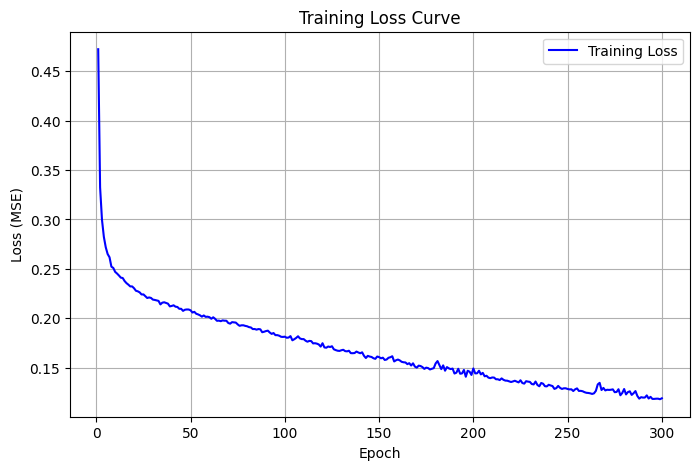

In [10]:
# Improved deeper MLP model with dropout and batch norm

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Train-test split

# Reshape target y if 1D to 2D for scaler compatibility
if y_train.ndim == 1:
    y_train = np.asarray(y_train).reshape(-1, 1)
    y_test = np.asarray(y_test).reshape(-1, 1)

# Standardize inputs and targets
scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)

X_train_scaled = scaler_X.transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

# Improved deeper MLP model with dropout and batch norm
class ImprovedMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(ImprovedMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
        
    def forward(self, x):
        return self.network(x)

input_dim = X_train_t.shape[1]
output_dim = y_train_t.shape[1]

model = ImprovedMLP(input_dim, output_dim)

# Optimizer and loss function
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.SmoothL1Loss()  # Huber loss

# Training

losses = []
num_epochs=300
model.train()
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), losses, label='Training Loss', color='blue')
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(True)

# Evaluation
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_t).numpy()
    y_pred_test = model(X_test_t).numpy()

# Inverse transform predictions and ground truth
y_pred_train_orig = scaler_y.inverse_transform(y_pred_train)
y_pred_test_orig = scaler_y.inverse_transform(y_pred_test)
y_train_orig = scaler_y.inverse_transform(y_train_scaled)
y_test_orig = scaler_y.inverse_transform(y_test_scaled)

# Compute metrics
r2_train = r2_score(y_train_orig, y_pred_train_orig)
r2_test = r2_score(y_test_orig, y_pred_test_orig)
mae_test = mean_absolute_error(y_test_orig, y_pred_test_orig)

print(f"Train R^2: {r2_train:.3f}")
print(f"Test R^2: {r2_test:.3f}")
print(f"Test MAE: {mae_test:.3f}")


In [ ]:
import matplotlib.pyplot as plt

# Training loop with loss tracking
num_epochs = 200
losses = []

model.train()
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), losses, label='Training Loss', color='blue')
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming y_true and y_pred arrays in original scale
def plot_true_vs_pred(y_true, y_pred, property_name="Ellipticity"):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, s=10, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel(f"True {property_name}")
    plt.ylabel(f"Predicted {property_name}")
    plt.title("True vs Predicted AION")
    plt.grid(True)
    plt.xlim(-0.1,1)
    plt.ylim(-0.1,1)
    plt.show()

def plot_residuals(y_true, y_pred):
    residuals = y_true - y_pred
    plt.figure(figsize=(6,4))
    plt.scatter(y_true, residuals, s=10, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("True Value")
    plt.ylabel("Residual (True - Predicted)")
    plt.title("Residuals Plot AION")
    plt.grid(True)
    plt.show()

def plot_distributions(y_true, y_pred):
    plt.figure(figsize=(6,4))
    plt.hist(y_true, bins=50, alpha=0.5, label="True", density=True)
    plt.hist(y_pred, bins=50, alpha=0.5, label="Predicted", density=True)
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.title("Distribution Comparison AION")
  
    plt.legend()
    plt.show()


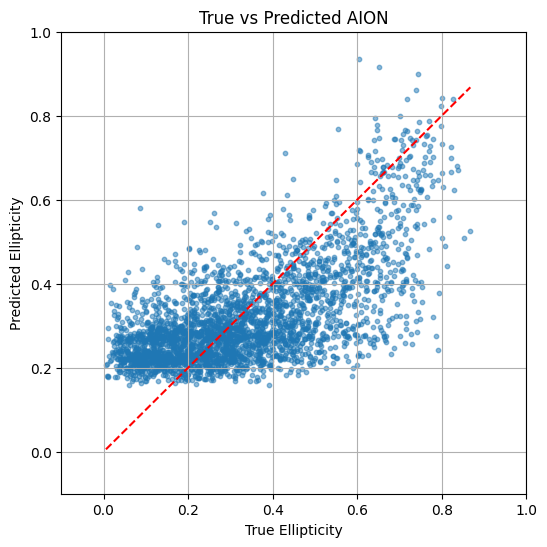

In [44]:
plot_true_vs_pred(y_test,y_pred_test)

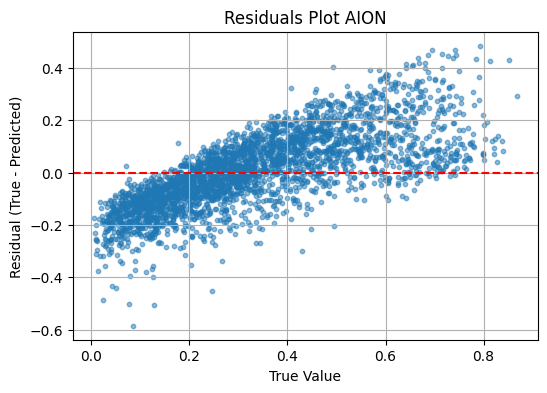

In [36]:
plot_residuals(y_test,y_pred_test)

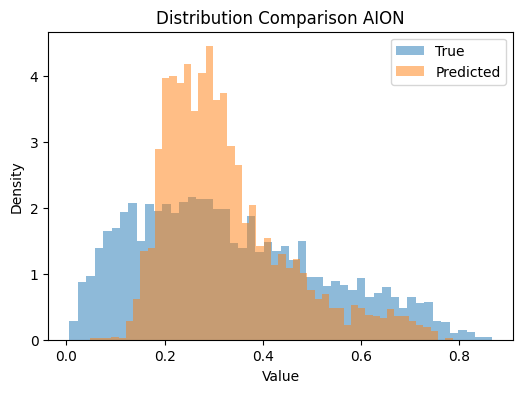

In [37]:
plot_distributions(y_test,y_pred_test)

In [29]:
import numpy as np

def percentage_well_predicted(y_true, y_pred, tolerance=0.1):
    """
    Calculate percentage of predictions with absolute percentage error <= tolerance.

    Parameters:
    - y_true: numpy array of true values
    - y_pred: numpy array of predicted values
    - tolerance: float, e.g., 0.1 means 10% error tolerance

    Returns:
    - percent: float, percentage (0-100) of well-predicted samples
    """
    # Avoid division by zero by adding a small epsilon (or exclude zero targets)
    epsilon = 1e-8
    ape = np.abs(y_true - y_pred) / (np.abs(y_true) + epsilon)
    well_predicted_count = np.sum(ape <= tolerance)
    percent = 100 * well_predicted_count / len(y_true)
    return percent

# Example usage
percent_10pct = percentage_well_predicted(y_test.flatten(), y_pred_test.flatten(), tolerance=0.1)
print(f"Percentage of predictions within 10% error: {percent_10pct:.2f}%")


Percentage of predictions within 10% error: 18.87%


In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Initialize the KNN regressor
knn = KNeighborsRegressor(n_neighbors=20,weights='distance')

# Fit the KNN model
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred_test = knn.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred_test)
print(f'Mean Squared Error: {mse}')


Mean Squared Error: 0.02022671566478137


In [17]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search over
param_grid = {'n_neighbors': [1, 3, 5, 7, 10, 15, 20], 'weights': ['uniform', 'distance']}

# Initialize the KNN regressor
knn = KNeighborsRegressor()

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the grid search
grid_search.fit(X_train, y_train)

# Best parameters found
print("Best parameters:", grid_search.best_params_)

# Evaluate the best model
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error with Grid Search: {mse}')


Best parameters: {'n_neighbors': 20, 'weights': 'distance'}
Mean Squared Error with Grid Search: 0.02022671566478137


In [45]:
from sklearn.ensemble import BaggingRegressor

# Initialize the base KNN regressor
base_knn = KNeighborsRegressor(n_neighbors=15)

# Initialize bagging regressor with base KNN
bagging_knn = BaggingRegressor(base_knn, n_estimators=50, random_state=42)

# Fit the model
bagging_knn.fit(X_train, y_train)

# Evaluate the model
y_pred = bagging_knn.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error with Bagging: {mse}')


/pbs/throng/training/astroinfo2025/env/astroclip-conda/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:583: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)


Mean Squared Error with Bagging: 0.019886350259184837


In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Define model
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.layers(x)

model = MLP(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Train
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

# Evaluate
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)
mse = criterion(y_pred_test, y_test).item()
print("MSE:", mse)


/tmp/ipykernel_58641/1764115523.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
/tmp/ipykernel_58641/1764115523.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
/tmp/ipykernel_58641/1764115523.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)
/tmp/ipykernel_58641/1764115523.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor

MSE: 0.020935241132974625
